<a href="https://colab.research.google.com/github/MinoliPerera021126/multi-class-species-classification-with-pytorch-neural-network/blob/main/iris_image_classification_with_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌸 Flower Image Classification with PyTorch

### Dataset: `alxmamaev/flowers-recognition` (Kaggle)

---

## 📋 What you'll learn in this notebook:
1. Download a Kaggle image dataset directly into Colab
2. Explore & visualize image data
3. Apply data augmentation to prevent overfitting
4. Build a **Custom CNN** from scratch
5. Use **Transfer Learning** with a pretrained ResNet-18 (more accurate!)
6. Trainevaluate and plot results
7. Run inference on new images

---

> 💡 **Runtime Tip:** Go to `Runtime → Change runtime type → T4 GPU` before running!


## 📦 Step 1 — Install & Import Libraries

In [1]:
# ── Install kaggle API (needed to download the dataset) ──────────────────────
!pip install kaggle --quiet

# ── Standard library imports ─────────────────────────────────────────────────
import os
import json
import random
import shutil
import zipfile
from pathlib import Path
from collections import Counter

# ── Data & visualisation ─────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image                     # PIL opens image files

# ── PyTorch core ──────────────────────────────────────────────────────────────
import torch
import torch.nn as nn                     # building blocks for neural networks
import torch.optim as optim               # optimisers (Adam, SGD, …)
import torch.nn.functional as F           # loss functions, activations, etc.
from torch.utils.data import DataLoader, random_split

# ── torchvision: datasets, transforms, pretrained models ─────────────────────
import torchvision
from torchvision import datasets, transforms, models

# ── scikit-learn: confusion matrix & classification report ───────────────────
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device: use GPU if available, else CPU ───────────────────────────────────
# On Colab with a T4 GPU this will print "Using device: cuda"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Using device: {DEVICE}")
print(f"🔥 PyTorch version: {torch.__version__}")

🖥️  Using device: cuda
🔥 PyTorch version: 2.10.0+cu128


## 🔑 Step 2 — Authenticate with Kaggle
    
You need a **kaggle.json** API key to download datasets.  
    
👉 Get yours at: `https://www.kaggle.com/settings/account` → **Create New Token**

In [2]:
# ── Upload your kaggle.json key ───────────────────────────────────────────────
# This pops up a file-chooser dialog — select your kaggle.json file
from google.colab import files

print("⬆️  Please upload your kaggle.json file ...")
uploaded = files.upload()   # <── click 'Choose Files' and select kaggle.json

# ── Move it to the location Kaggle API expects ───────────────────────────────
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
shutil.move("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)  # secure the key

print("✅ kaggle.json saved successfully!")

⬆️  Please upload your kaggle.json file ...


Saving kaggle.json to kaggle.json
✅ kaggle.json saved successfully!


## 📥 Step 3 — Download & Extract the Dataset

In [3]:
# ── Download the flowers dataset from Kaggle ─────────────────────────────────
# The dataset has ~4,300 images across 5 flower classes
print("⬇️  Downloading dataset (this may take ~1 minute) ...")
!kaggle datasets download -d alxmamaev/flowers-recognition

# ── Unzip the downloaded archive ──────────────────────────────────────────────
print("\n📂 Extracting zip file ...")
with zipfile.ZipFile("flowers-recognition.zip", "r") as zf:
    zf.extractall("flowers_data")

# ── Find the actual data root (handles nested folders in the zip) ─────────────
# The dataset unzips to:  flowers_data/flowers/daisy/, roses/, etc.
DATA_ROOT = None
for root, dirs, files_ in os.walk("flowers_data"):
    if "daisy" in dirs:                  # daisy is one of the 5 class folders
        DATA_ROOT = Path(root)
        break

assert DATA_ROOT is not None, "Could not find flower class folders!"
print(f"\n✅ Dataset root: {DATA_ROOT}")
print("📁 Classes found:", sorted(os.listdir(DATA_ROOT)))

⬇️  Downloading dataset (this may take ~1 minute) ...
Dataset URL: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition
License(s): unknown
flowers-recognition.zip: Skipping, found more recently modified local copy (use --force to force download)

📂 Extracting zip file ...

✅ Dataset root: flowers_data/flowers
📁 Classes found: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


## 🔍 Step 4 — Explore the Dataset

In [4]:
# ── Count images per class ────────────────────────────────────────────────────
CLASS_NAMES = sorted([d for d in os.listdir(DATA_ROOT)
                      if os.path.isdir(DATA_ROOT / d)])
NUM_CLASSES = len(CLASS_NAMES)

print(f"🌸 Number of classes : {NUM_CLASSES}")
print(f"📛 Class names       : {CLASS_NAMES}\n")

counts = {}
for cls in CLASS_NAMES:
    imgs = list((DATA_ROOT / cls).glob("*.jpg")) + \
           list((DATA_ROOT / cls).glob("*.jpeg")) + \
           list((DATA_ROOT / cls).glob("*.png"))
    counts[cls] = len(imgs)
    print(f"  {cls:15s}: {len(imgs):4d} images")

print(f"\n📊 Total images: {sum(counts.values())}")

🌸 Number of classes : 5
📛 Class names       : ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

  daisy          :  764 images
  dandelion      : 1052 images
  rose           :  784 images
  sunflower      :  733 images
  tulip          :  984 images

📊 Total images: 4317


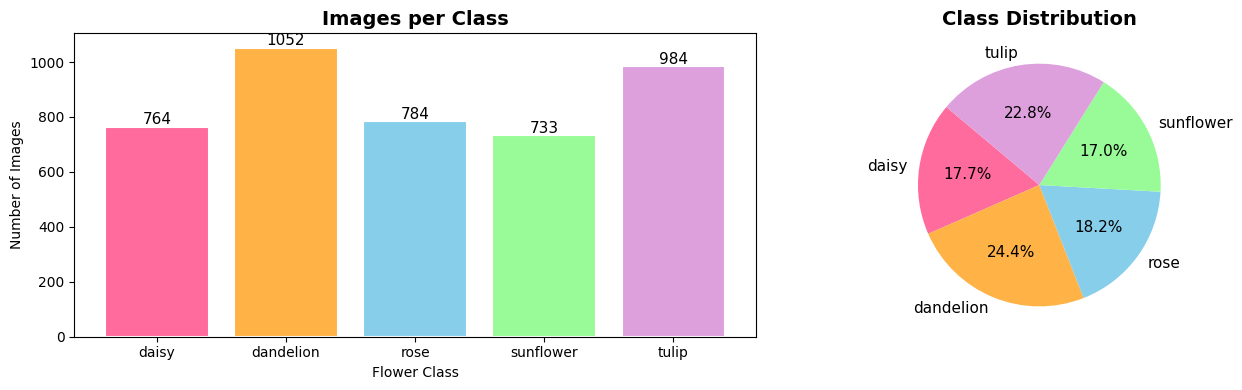

In [5]:
# ── Bar chart: class distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar plot
colors = ["#FF6B9D", "#FFB347", "#87CEEB", "#98FB98", "#DDA0DD"]
axes[0].bar(counts.keys(), counts.values(), color=colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("Images per Class", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Flower Class")
axes[0].set_ylabel("Number of Images")
for i, (k, v) in enumerate(counts.items()):
    axes[0].text(i, v + 10, str(v), ha="center", fontsize=11)

# Pie chart
axes[1].pie(counts.values(), labels=counts.keys(), colors=colors,
            autopct="%1.1f%%", startangle=140,
            textprops={"fontsize": 11})
axes[1].set_title("Class Distribution", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
# ── Visualise sample images from each class ───────────────────────────────────
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(14, NUM_CLASSES * 2.8))
fig.suptitle("Sample Images from Each Flower Class", fontsize=16, fontweight="bold", y=1.01)

for row, cls in enumerate(CLASS_NAMES):
    img_paths = list((DATA_ROOT / cls).glob("*.jpg")) + \
                list((DATA_ROOT / cls).glob("*.jpeg"))
    samples = random.sample(img_paths, min(5, len(img_paths)))

    for col, img_path in enumerate(samples):
        img = Image.open(img_path).convert("RGB")
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(cls.upper(), fontsize=11,
                                      fontweight="bold", rotation=90,
                                      labelpad=10, color="#333")
            axes[row, col].yaxis.set_label_position("left")
            axes[row, col].yaxis.label.set_visible(True)

plt.tight_layout()
plt.show()

## 🔄 Step 5 — Data Transforms & Augmentation

**Why augmentation?**

We have ~4300 images — not a lot. Augmentation artificially expands the dataset by randomly flipping rotating and colour-jittering images *during training* so the model doesn't just memorise the training set (overfitting).

| Transform | Purpose |
|---|---|
| `RandomHorizontalFlip` | Flowers look the same mirrored |
| `RandomRotation` | Handle photos taken at an angle |
| `ColorJitter` | Handle different lighting conditions |
| `RandomResizedCrop` | Focus on different parts of the flower |
| `Normalize` | Scale pixel values to match ImageNet stats (required for pretrained models) |

In [6]:
# ── Image size: ResNet expects 224×224 ────────────────────────────────────────
IMG_SIZE = 224

# ImageNet mean & std — we use these because our pretrained model was trained
# on ImageNet and its weights expect inputs normalised this way.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Training transforms: augmentation + normalisation ────────────────────────
train_transforms = transforms.Compose([
    # Randomly crop a region and resize it to IMG_SIZE
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    # 50% chance of flipping the image left-right
    transforms.RandomHorizontalFlip(p=0.5),
    # Random vertical flip — optional for flowers
    transforms.RandomVerticalFlip(p=0.1),
    # Randomly adjust brightness, contrast, saturation, hue
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    # Randomly rotate up to ±30 degrees
    transforms.RandomRotation(degrees=30),
    # Convert PIL Image to a PyTorch tensor (also scales to 0–1)
    transforms.ToTensor(),
    # Normalise with ImageNet statistics
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── Validation/Test transforms: NO augmentation, just resize + normalise ─────
# We want a fair, consistent evaluation — no random changes during val/test
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("✅ Transforms defined!")

✅ Transforms defined!


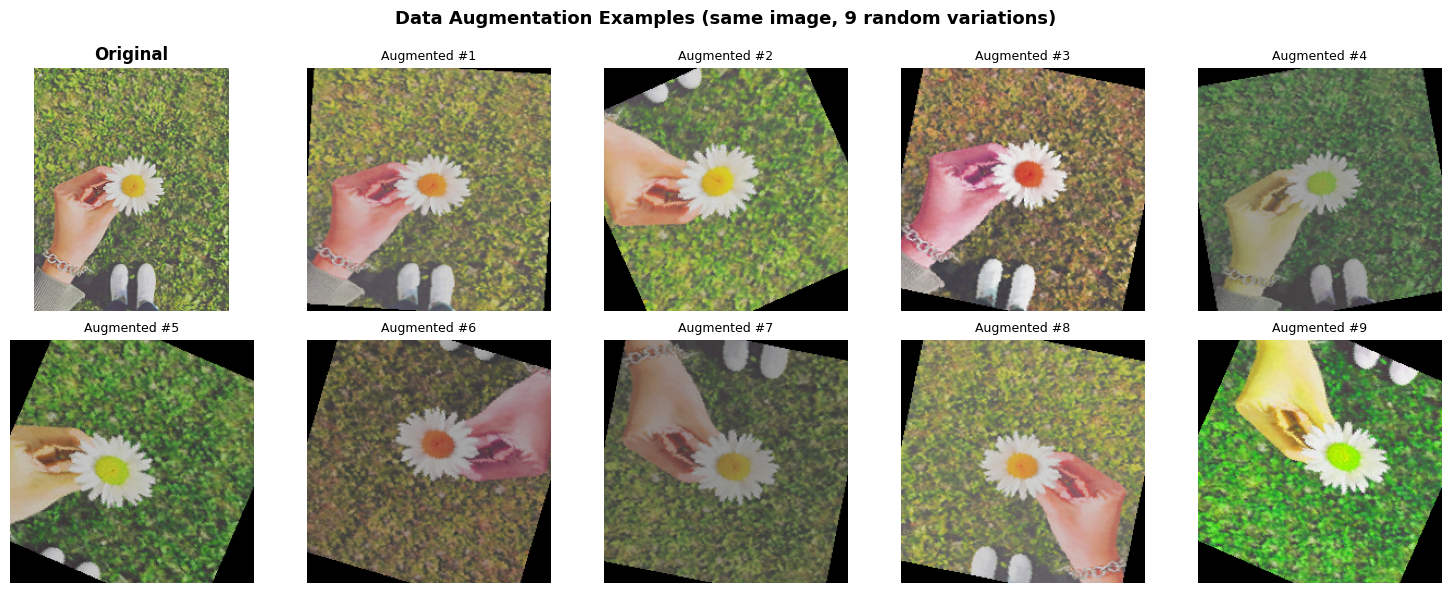

In [7]:
# ── Visualise augmented images ─────────────────────────────────────────────────
# Pick one image and apply augmentations 10 times to see the variety
sample_img_path = list((DATA_ROOT / CLASS_NAMES[0]).glob("*.jpg"))[0]
sample_pil = Image.open(sample_img_path).convert("RGB")

# Helper: un-normalise a tensor for display
def denorm(tensor):
    """Reverse ImageNet normalisation so we can display the tensor as an image."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

# Original
axes[0].imshow(sample_pil)
axes[0].set_title("Original", fontweight="bold")
axes[0].axis("off")

# 9 augmented versions
for i in range(1, 10):
    aug_tensor = train_transforms(sample_pil)   # each call is random!
    aug_img = denorm(aug_tensor).permute(1, 2, 0).numpy()  # CHW → HWC for matplotlib
    axes[i].imshow(aug_img)
    axes[i].set_title(f"Augmented #{i}", fontsize=9)
    axes[i].axis("off")

fig.suptitle("Data Augmentation Examples (same image, 9 random variations)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 📂 Step 6 — Create Datasets & DataLoaders

We split the full dataset into **Train / Validation / Test** (70 / 15 / 15).

In [8]:
# ── Load full dataset with torchvision.datasets.ImageFolder ───────────────────
# ImageFolder automatically assigns class labels based on subfolder names.
# Folder structure expected:
#   flowers/
#     daisy/   img1.jpg, img2.jpg …
#     dandelion/
#     rose/
#     sunflower/
#     tulip/

full_dataset = datasets.ImageFolder(root=str(DATA_ROOT))
CLASS_NAMES  = full_dataset.classes          # ['daisy', 'dandelion', ...]
NUM_CLASSES  = len(CLASS_NAMES)
TOTAL        = len(full_dataset)

print(f"Total images  : {TOTAL}")
print(f"Classes       : {CLASS_NAMES}")
print(f"Class→Index   : {full_dataset.class_to_idx}")

# ── Compute split sizes ───────────────────────────────────────────────────────
val_size  = int(0.15 * TOTAL)
test_size = int(0.15 * TOTAL)
train_size = TOTAL - val_size - test_size

print(f"\nTrain : {train_size} | Val : {val_size} | Test : {test_size}")

# ── Random split (reproducible because we set SEED earlier) ──────────────────
train_set, val_set, test_set = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

# ── Assign the correct transforms to each split ───────────────────────────────
# random_split returns Subset objects; we override their dataset's transform
# by wrapping them in a small helper.
class TransformSubset(torch.utils.data.Dataset):
    """Applies a given transform to a Subset."""
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        # img is a PIL image from ImageFolder (default loader)
        if self.transform:
            img = self.transform(img)
        return img, label

# Attach transforms
train_data = TransformSubset(train_set, train_transforms)
val_data   = TransformSubset(val_set,   val_test_transforms)
test_data  = TransformSubset(test_set,  val_test_transforms)

# ── DataLoaders: batch the data and shuffle training set ─────────────────────
BATCH_SIZE = 32   # images per batch — adjust down to 16 if you run out of GPU memory

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print("\n✅ DataLoaders ready!")
print(f"   Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Total images  : 4317
Classes       : ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Class→Index   : {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}

Train : 3023 | Val : 647 | Test : 647

✅ DataLoaders ready!
   Batches — Train: 95 | Val: 21 | Test: 21


Batch shape : torch.Size([32, 3, 224, 224])
  → (batch_size=32, channels=3, H=224, W=224)
Labels shape: torch.Size([32])
Label values: [1, 0, 2, 4, 1, 0, 4, 3]  → ['dandelion', 'daisy', 'rose', 'tulip', 'dandelion', 'daisy', 'tulip', 'sunflower']


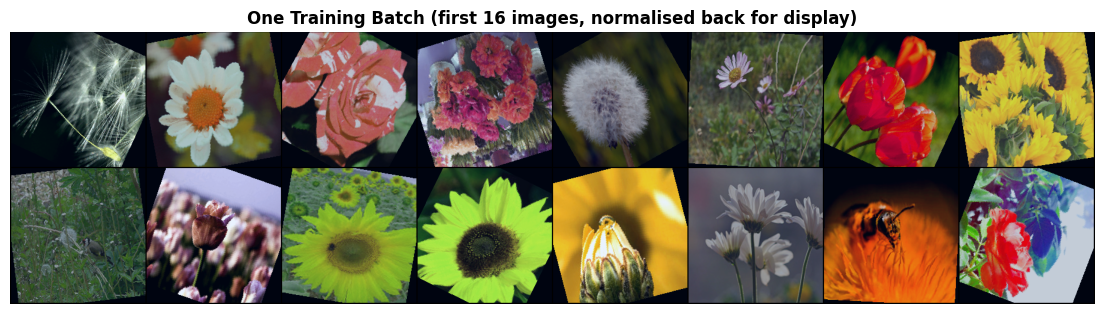

In [9]:
# ── Inspect one batch ─────────────────────────────────────────────────────────
images, labels = next(iter(train_loader))
print(f"Batch shape : {images.shape}")
print(f"  → (batch_size={images.shape[0]}, channels={images.shape[1]}, "
      f"H={images.shape[2]}, W={images.shape[3]})")
print(f"Labels shape: {labels.shape}")
print(f"Label values: {labels[:8].tolist()}  "
      f"→ {[CLASS_NAMES[l] for l in labels[:8].tolist()]}")

# ── Show a grid of batch images ───────────────────────────────────────────────
grid = torchvision.utils.make_grid(images[:16], nrow=8, padding=2, normalize=True)
plt.figure(figsize=(14, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.title("One Training Batch (first 16 images, normalised back for display)",
          fontsize=12, fontweight="bold")
plt.axis("off")
plt.show()

## 🏗️ Step 7 — Model A: Custom CNN from Scratch

A **Convolutional Neural Network (CNN)** learns to detect edges → textures → patterns → objects.  
Each `Conv → BatchNorm → ReLU → MaxPool` block doubles the semantic richness while halving spatial size.
```
Input (3×224×224)
  ↓  Conv block 1 → 32 feature maps  (112×112)
  ↓  Conv block 2 → 64 feature maps  ( 56×56)
  ↓  Conv block 3 → 128 feature maps ( 28×28)
  ↓  Conv block 4 → 256 feature maps ( 14×14)
  ↓  Global Average Pooling          (1×1)
  ↓  Fully-connected layers
  ↓  Output (5 classes)
  
```

In [10]:
class FlowerCNN(nn.Module):
    """Custom CNN for flower classification."""

    def __init__(self, num_classes=5):
        super(FlowerCNN, self).__init__()

        # ── Helper: one Conv → BatchNorm → ReLU → MaxPool block ──────────────
        def conv_block(in_channels, out_channels, pool=True):
            layers = [
                # Conv2d learns spatial features (3×3 kernel)
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                # BatchNorm stabilises training by normalising each mini-batch
                nn.BatchNorm2d(out_channels),
                # ReLU: non-linear activation — sets negatives to 0
                nn.ReLU(inplace=True),
            ]
            if pool:
                # MaxPool halves the spatial dimensions (H, W → H/2, W/2)
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            return nn.Sequential(*layers)

        # ── Feature extractor (convolutional backbone) ─────────────────────
        self.features = nn.Sequential(
            conv_block(3,   32),   # 3 RGB channels  → 32 feature maps
            conv_block(32,  64),   # 32              → 64
            conv_block(64,  128),  # 64              → 128
            conv_block(128, 256),  # 128             → 256
        )

        # Global Average Pooling: collapses spatial dims to 1×1
        # This makes the model robust to input size changes
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        # ── Classifier (fully-connected head) ──────────────────────────────
        self.classifier = nn.Sequential(
            nn.Flatten(),             # flatten (256, 1, 1) → 256
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),        # Dropout: randomly zeros 40% of neurons → reduces overfitting
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(128, num_classes),  # final output: one score per class
        )

    def forward(self, x):
        """Forward pass: x is a batch of images (B, 3, 224, 224)."""
        x = self.features(x)          # extract spatial features
        x = self.global_avg_pool(x)   # (B, 256, 14, 14) → (B, 256, 1, 1)
        x = self.classifier(x)        # produce class logits
        return x


# ── Instantiate and inspect ────────────────────────────────────────────────────
cnn_model = FlowerCNN(num_classes=NUM_CLASSES).to(DEVICE)

# Count trainable parameters
total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"🧠 Custom CNN — Trainable parameters: {total_params:,}")
print(cnn_model)

🧠 Custom CNN — Trainable parameters: 587,269
FlowerCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mo

## 🚀 Step 8 — Model B: Transfer Learning with ResNet-18
**Transfer Learning** means: take a model already trained on millions of ImageNet images and adapt it to our task.  
- The early layers already know how to detect **edges textures shapes** — we keep those.
- We replace only the **final classification layer** with our own 5-class head and retrain.

> 🏆 Transfer learning almost always beats training from scratch with small datasets!

In [11]:
def build_resnet_model(num_classes, freeze_backbone=False):
    """
    Build a ResNet-18 model for transfer learning.

    Args:
        num_classes    : number of output classes
        freeze_backbone: if True, only train the final layer (feature extraction mode)
                         if False, train all layers (fine-tuning mode — usually better)
    """
    # Load ResNet-18 pretrained on ImageNet
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        # Freeze all pretrained weights — only the new head will be trained
        for param in model.parameters():
            param.requires_grad = False

    # ResNet's final layer is called `fc` (fully connected)
    # It was originally: Linear(512, 1000) for 1000 ImageNet classes
    # We replace it with our custom head for 5 flower classes
    in_features = model.fc.in_features   # = 512 for ResNet-18
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.4),
        nn.Linear(256, num_classes),
    )

    return model


# ── We use fine-tuning (freeze_backbone=False) for best accuracy ──────────────
resnet_model = build_resnet_model(NUM_CLASSES, freeze_backbone=False).to(DEVICE)

total_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f"🧠 ResNet-18 (fine-tune) — Trainable parameters: {total_params:,}")

🧠 ResNet-18 (fine-tune) — Trainable parameters: 11,309,125


## ⚙️ Step 9 — Training Utilities

We write reusable `train_one_epoch` and `evaluate` functions then call them in a loop.

In [12]:
def train_one_epoch(model, loader, criterion, optimiser, device):
    """
    Run one full pass over the training set.
    Returns average loss and accuracy for the epoch.
    """
    model.train()           # switch to training mode (enables dropout, batchnorm updating)
    total_loss, correct, total = 0.0, 0, 0

    for batch_idx, (images, labels) in enumerate(loader):
        # Move data to GPU (or CPU if no GPU)
        images, labels = images.to(device), labels.to(device)

        # ── Forward pass ──────────────────────────────────────────────────────
        optimiser.zero_grad()           # clear gradients from last step
        outputs = model(images)         # get raw scores (logits) for each class
        loss = criterion(outputs, labels)  # compute how wrong the predictions are

        # ── Backward pass ─────────────────────────────────────────────────────
        loss.backward()                 # compute gradients via backpropagation
        optimiser.step()               # update model weights

        # ── Accumulate metrics ────────────────────────────────────────────────
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)   # class with highest score
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


@torch.no_grad()   # decorator: disable gradient tracking (saves memory + speed)
def evaluate(model, loader, criterion, device):
    """
    Evaluate the model on a validation or test set.
    Returns average loss and accuracy.
    """
    model.eval()            # switch to evaluation mode (disables dropout)
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, num_epochs,
                learning_rate, weight_decay, device, model_name="model"):
    """
    Full training loop with:
    - Adam optimiser
    - ReduceLROnPlateau scheduler (reduces LR when val loss stops improving)
    - Best model checkpoint saving
    """
    # ── Loss function: CrossEntropy (standard for multi-class classification) ─
    criterion = nn.CrossEntropyLoss()

    # ── Optimiser: Adam adapts the learning rate per parameter ────────────────
    optimiser = optim.Adam(model.parameters(),
                           lr=learning_rate,
                           weight_decay=weight_decay)  # weight_decay = L2 regularisation

    # ── LR Scheduler: halve LR if val_loss doesn't improve for 3 epochs ──────
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode="min", factor=0.5, patience=3
    )

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0
    best_ckpt    = f"best_{model_name}.pth"

    print(f"\n{'='*60}")
    print(f" Training {model_name} for {num_epochs} epochs")
    print(f"{'='*60}\n")

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion,
                                                optimiser, device)
        val_loss, val_acc     = evaluate(model, val_loader, criterion, device)
        scheduler.step(val_loss)  # adjust LR based on validation loss

        # Log metrics
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        # Save the best model so far
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_ckpt)
            flag = " ✅ (best)"
        else:
            flag = ""

        print(f"Epoch [{epoch:02d}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.2f}%  "
              f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc*100:.2f}%{flag}")

    print(f"\n🏆 Best Val Accuracy: {best_val_acc*100:.2f}%  (saved to '{best_ckpt}')")
    return history, best_ckpt


print("✅ Training utilities defined!")

✅ Training utilities defined!


## 🎯 Step 10A — Train the Custom CNN

In [13]:
CNN_EPOCHS = 20          # train for 20 epochs
CNN_LR     = 3e-4        # learning rate: how big each weight update step is
CNN_WD     = 1e-4        # weight decay: penalises large weights (regularisation)

cnn_history, cnn_ckpt = train_model(
    model        = cnn_model,
    train_loader = train_loader,
    val_loader   = val_loader,
    num_epochs   = CNN_EPOCHS,
    learning_rate= CNN_LR,
    weight_decay = CNN_WD,
    device       = DEVICE,
    model_name   = "FlowerCNN"
)


 Training FlowerCNN for 20 epochs

Epoch [01/20] Train Loss: 1.3910  Train Acc: 41.22%  Val Loss: 1.2907  Val Acc: 44.82% ✅ (best)
Epoch [02/20] Train Loss: 1.2567  Train Acc: 48.13%  Val Loss: 1.1732  Val Acc: 50.39% ✅ (best)
Epoch [03/20] Train Loss: 1.1623  Train Acc: 52.70%  Val Loss: 1.0485  Val Acc: 57.65% ✅ (best)
Epoch [04/20] Train Loss: 1.1123  Train Acc: 55.47%  Val Loss: 0.9609  Val Acc: 60.12% ✅ (best)
Epoch [05/20] Train Loss: 1.0840  Train Acc: 57.10%  Val Loss: 0.9503  Val Acc: 57.34%
Epoch [06/20] Train Loss: 1.0378  Train Acc: 59.31%  Val Loss: 1.0429  Val Acc: 59.35%
Epoch [07/20] Train Loss: 1.0174  Train Acc: 60.87%  Val Loss: 1.2659  Val Acc: 52.09%
Epoch [08/20] Train Loss: 0.9966  Train Acc: 60.54%  Val Loss: 0.9871  Val Acc: 60.43% ✅ (best)
Epoch [09/20] Train Loss: 0.9809  Train Acc: 62.12%  Val Loss: 0.9064  Val Acc: 65.22% ✅ (best)
Epoch [10/20] Train Loss: 0.9599  Train Acc: 63.05%  Val Loss: 0.9919  Val Acc: 58.89%
Epoch [11/20] Train Loss: 0.9547  Train 

## 🎯 Step 10B — Train the ResNet-18 (Transfer Learning)

In [14]:
RESNET_EPOCHS = 15      # fewer epochs needed — pretrained weights already good
RESNET_LR     = 1e-4   # smaller LR when fine-tuning to avoid destroying pretrained weights
RESNET_WD     = 1e-4

resnet_history, resnet_ckpt = train_model(
    model        = resnet_model,
    train_loader = train_loader,
    val_loader   = val_loader,
    num_epochs   = RESNET_EPOCHS,
    learning_rate= RESNET_LR,
    weight_decay = RESNET_WD,
    device       = DEVICE,
    model_name   = "ResNet18"
)


 Training ResNet18 for 15 epochs

Epoch [01/15] Train Loss: 0.7082  Train Acc: 75.59%  Val Loss: 0.3750  Val Acc: 85.63% ✅ (best)
Epoch [02/15] Train Loss: 0.3334  Train Acc: 88.12%  Val Loss: 0.2591  Val Acc: 91.19% ✅ (best)
Epoch [03/15] Train Loss: 0.2663  Train Acc: 91.04%  Val Loss: 0.2795  Val Acc: 90.42%
Epoch [04/15] Train Loss: 0.2207  Train Acc: 92.23%  Val Loss: 0.2126  Val Acc: 91.65% ✅ (best)
Epoch [05/15] Train Loss: 0.1806  Train Acc: 93.81%  Val Loss: 0.3090  Val Acc: 89.03%
Epoch [06/15] Train Loss: 0.1493  Train Acc: 95.04%  Val Loss: 0.2225  Val Acc: 92.27% ✅ (best)
Epoch [07/15] Train Loss: 0.1593  Train Acc: 94.81%  Val Loss: 0.2079  Val Acc: 93.20% ✅ (best)
Epoch [08/15] Train Loss: 0.1286  Train Acc: 95.40%  Val Loss: 0.2634  Val Acc: 92.27%
Epoch [09/15] Train Loss: 0.1353  Train Acc: 95.34%  Val Loss: 0.3045  Val Acc: 91.65%
Epoch [10/15] Train Loss: 0.1415  Train Acc: 95.10%  Val Loss: 0.2649  Val Acc: 91.50%
Epoch [11/15] Train Loss: 0.1014  Train Acc: 96.59

## 📈 Step 11 — Plot Training Curves

A good model shows:
- **Decreasing** train and val loss over epochs
- **Increasing** train and val accuracy
- Small **gap** between train and val curves (large gap → overfitting)

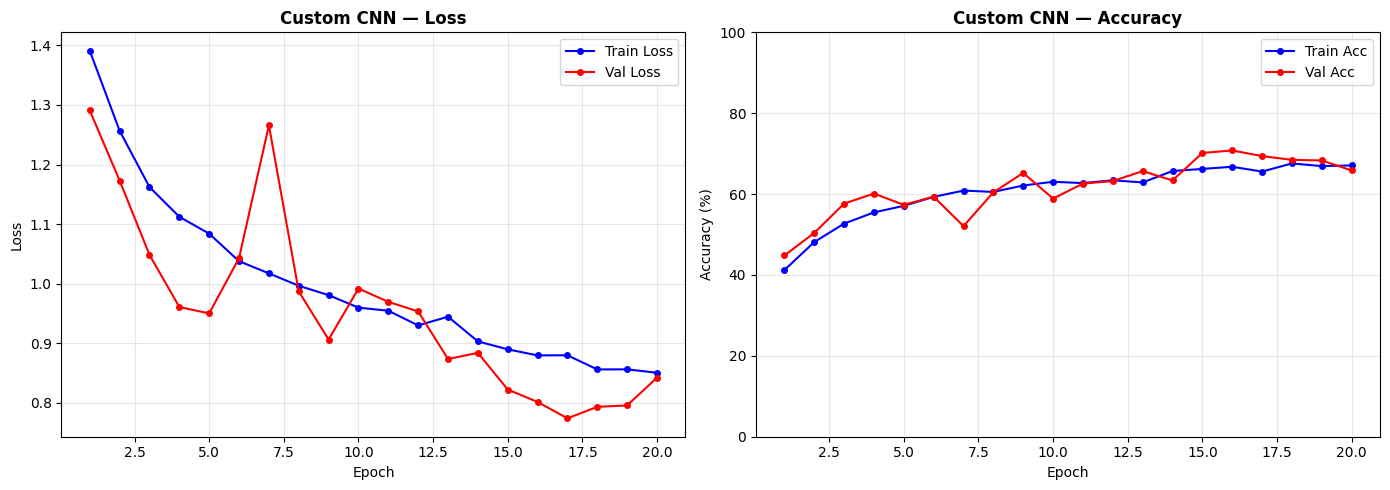

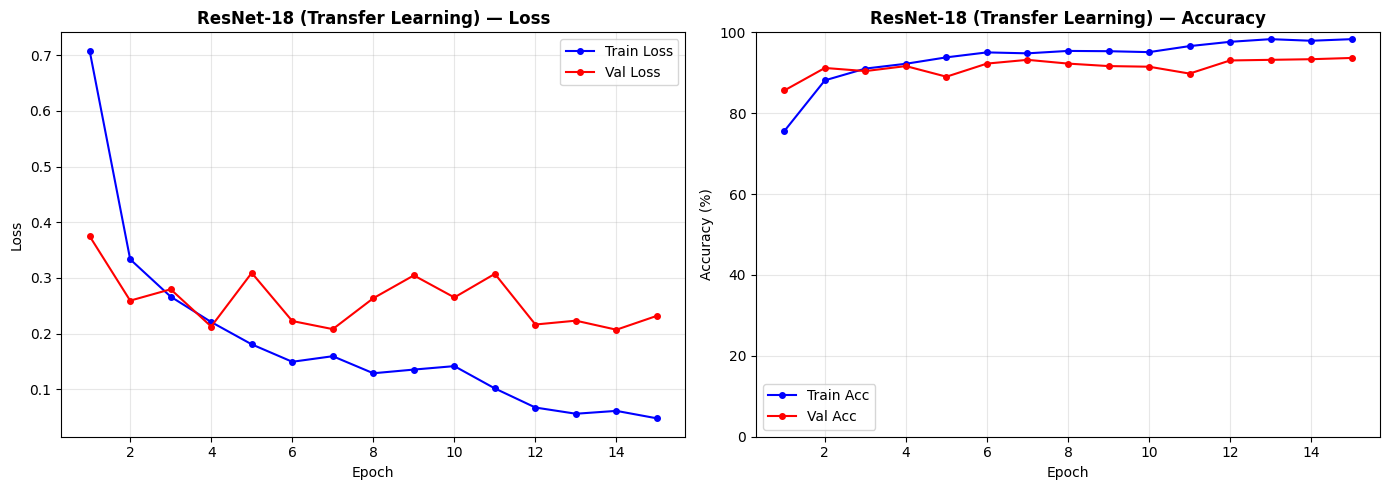

In [15]:
def plot_history(history, title="Training Curves"):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(epochs, history["train_loss"], "b-o", label="Train Loss", markersize=4)
    axes[0].plot(epochs, history["val_loss"],   "r-o", label="Val Loss",   markersize=4)
    axes[0].set_title(f"{title} — Loss", fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Accuracy
    train_acc_pct = [a * 100 for a in history["train_acc"]]
    val_acc_pct   = [a * 100 for a in history["val_acc"]]
    axes[1].plot(epochs, train_acc_pct, "b-o", label="Train Acc", markersize=4)
    axes[1].plot(epochs, val_acc_pct,   "r-o", label="Val Acc",   markersize=4)
    axes[1].set_title(f"{title} — Accuracy", fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[1].set_ylim(0, 100)

    plt.tight_layout()
    plt.show()

plot_history(cnn_history,    title="Custom CNN")
plot_history(resnet_history, title="ResNet-18 (Transfer Learning)")

## 🧪 Step 12 — Evaluate on Test Set

The test set was never seen during training — this gives us an honest estimate of real-world performance.

In [16]:
@torch.no_grad()
def get_all_preds_and_labels(model, loader, device):
    """Run the model on the full loader and collect all predictions + true labels."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)                          # raw logits
        probs   = torch.softmax(outputs, dim=1)          # convert to probabilities
        preds   = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_labels), np.array(all_probs)


# ── Load the BEST saved checkpoint for each model ─────────────────────────────
print("Loading best CNN checkpoint ...")
cnn_model.load_state_dict(torch.load(cnn_ckpt, map_location=DEVICE))

print("Loading best ResNet-18 checkpoint ...")
resnet_model.load_state_dict(torch.load(resnet_ckpt, map_location=DEVICE))

# ── Get predictions on test set ───────────────────────────────────────────────
cnn_preds,    cnn_labels,    cnn_probs    = get_all_preds_and_labels(cnn_model,    test_loader, DEVICE)
resnet_preds, resnet_labels, resnet_probs = get_all_preds_and_labels(resnet_model, test_loader, DEVICE)

# ── Print accuracy ────────────────────────────────────────────────────────────
cnn_acc    = (cnn_preds    == cnn_labels).mean()    * 100
resnet_acc = (resnet_preds == resnet_labels).mean() * 100

print(f"\n📊 Test Accuracy")
print(f"  Custom CNN       : {cnn_acc:.2f}%")
print(f"  ResNet-18 (TL)   : {resnet_acc:.2f}%")

Loading best CNN checkpoint ...
Loading best ResNet-18 checkpoint ...

📊 Test Accuracy
  Custom CNN       : 70.63%
  ResNet-18 (TL)   : 93.20%


In [17]:
# ── Full classification report (precision, recall, F1 per class) ──────────────
print("\n" + "="*55)
print(" Custom CNN — Classification Report")
print("="*55)
print(classification_report(cnn_labels, cnn_preds, target_names=CLASS_NAMES))

print("\n" + "="*55)
print(" ResNet-18 — Classification Report")
print("="*55)
print(classification_report(resnet_labels, resnet_preds, target_names=CLASS_NAMES))


 Custom CNN — Classification Report
              precision    recall  f1-score   support

       daisy       0.65      0.73      0.69       127
   dandelion       0.71      0.85      0.77       156
        rose       0.70      0.44      0.54       115
   sunflower       0.87      0.71      0.78       109
       tulip       0.66      0.74      0.70       140

    accuracy                           0.71       647
   macro avg       0.72      0.69      0.70       647
weighted avg       0.71      0.71      0.70       647


 ResNet-18 — Classification Report
              precision    recall  f1-score   support

       daisy       0.93      0.94      0.93       127
   dandelion       0.95      0.93      0.94       156
        rose       0.96      0.85      0.90       115
   sunflower       0.95      0.98      0.96       109
       tulip       0.88      0.96      0.92       140

    accuracy                           0.93       647
   macro avg       0.93      0.93      0.93       647
weig

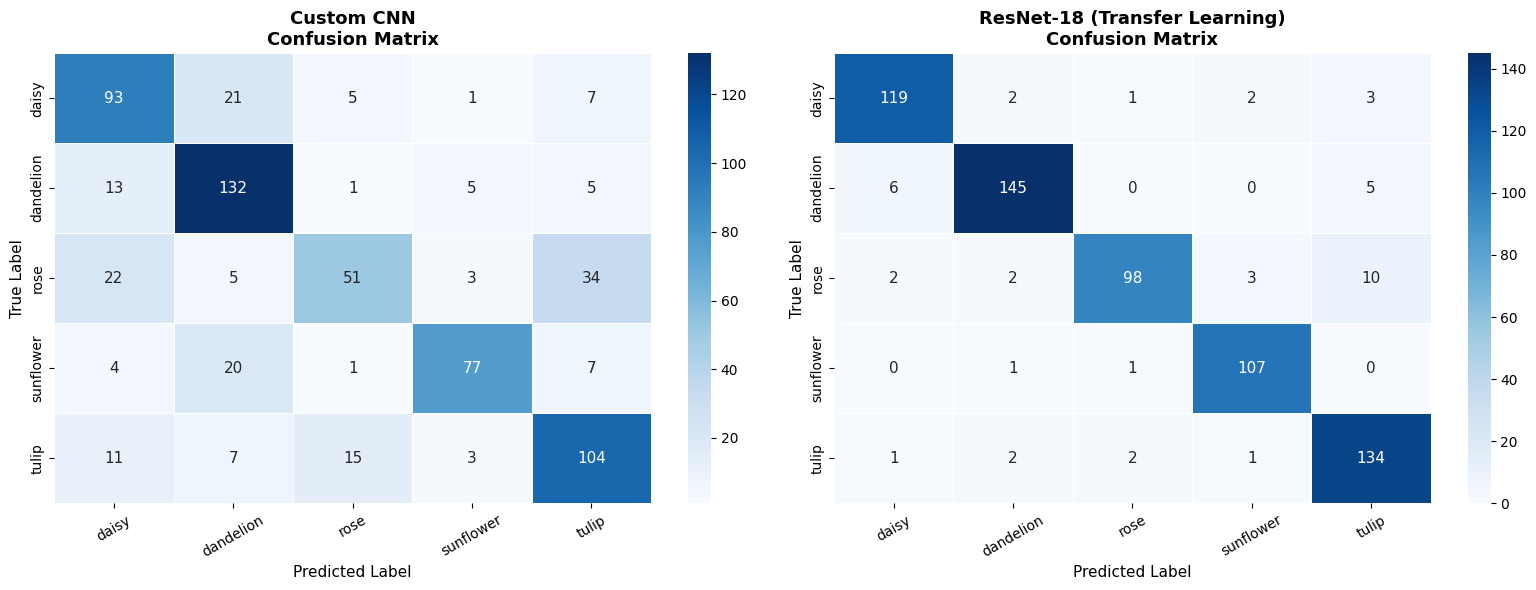

In [18]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
# A confusion matrix shows what the model predicted vs what the true label was.
# Diagonal = correct predictions; off-diagonal = mistakes.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, preds, labels, title in [
    (axes[0], cnn_preds,    cnn_labels,    "Custom CNN"),
    (axes[1], resnet_preds, resnet_labels, "ResNet-18 (Transfer Learning)"),
]:
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
                linewidths=0.5, annot_kws={"size": 11})
    ax.set_title(f"{title}\nConfusion Matrix", fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 🔬 Step 13 — Visualise Predictions (Correct & Wrong)

Seeing *which* images the model gets wrong helps us understand its failure modes.

/tmp/ipykernel_6178/2867078309.py:48: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6178/2867078309.py:48: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


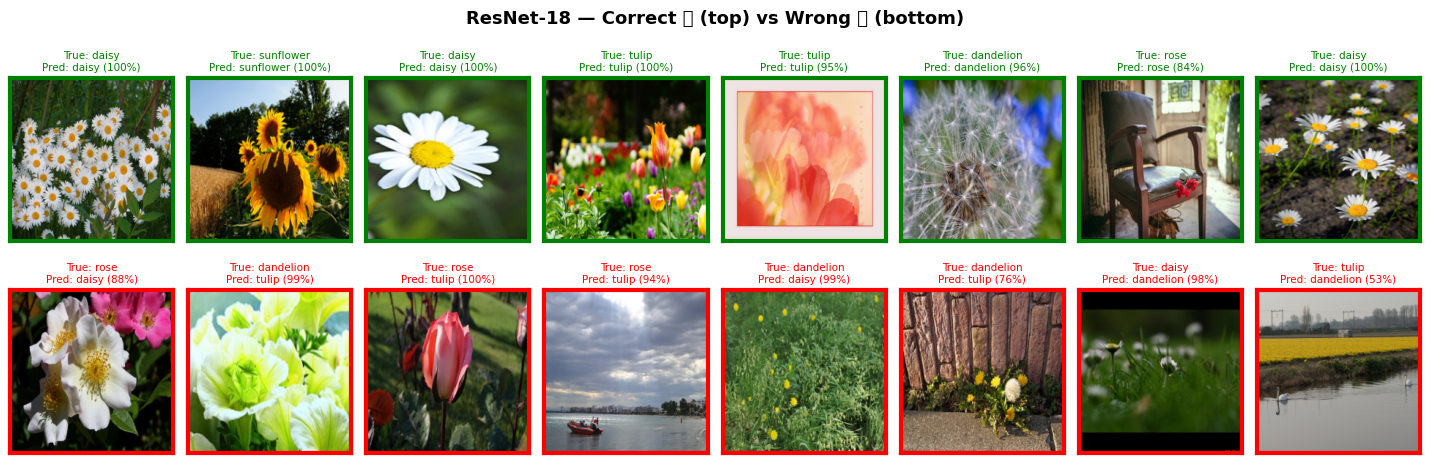

In [19]:
@torch.no_grad()
def visualise_predictions(model, dataset, class_names, device,
                           n_correct=8, n_wrong=8, model_name="Model"):
    """Show a grid of correct and incorrect predictions."""
    model.eval()

    correct_samples, wrong_samples = [], []
    indices = list(range(len(dataset)))
    random.shuffle(indices)

    for idx in indices:
        img_tensor, true_label = dataset[idx]
        output = model(img_tensor.unsqueeze(0).to(device))   # add batch dim
        pred   = output.argmax(dim=1).item()
        prob   = torch.softmax(output, dim=1)[0, pred].item()

        record = (img_tensor, true_label, pred, prob)
        if pred == true_label and len(correct_samples) < n_correct:
            correct_samples.append(record)
        elif pred != true_label and len(wrong_samples) < n_wrong:
            wrong_samples.append(record)

        if len(correct_samples) >= n_correct and len(wrong_samples) >= n_wrong:
            break

    def show_row(samples, ax_row, row_label, border_color):
        for col, (img_t, true_l, pred_l, prob) in enumerate(samples):
            img_disp = denorm(img_t).permute(1, 2, 0).numpy()
            ax_row[col].imshow(img_disp)
            ax_row[col].set_title(
                f"True: {class_names[true_l]}\nPred: {class_names[pred_l]} ({prob*100:.0f}%)",
                fontsize=7.5,
                color="green" if true_l == pred_l else "red"
            )
            for spine in ax_row[col].spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(3)
            ax_row[col].tick_params(left=False, bottom=False,
                                    labelleft=False, labelbottom=False)

    n_cols = max(n_correct, n_wrong)
    fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 1.8, 5))
    fig.suptitle(f"{model_name} — Correct ✅ (top) vs Wrong ❌ (bottom)",
                 fontsize=13, fontweight="bold")

    show_row(correct_samples, axes[0], "Correct", "green")
    show_row(wrong_samples,   axes[1], "Wrong",   "red")
    plt.tight_layout()
    plt.show()


# Use the best ResNet model
visualise_predictions(resnet_model, test_data, CLASS_NAMES, DEVICE,
                      model_name="ResNet-18")

## 🌡️ Step 14 — Confidence Distribution

A well-calibrated model should be **highly confident on correct predictions** and less confident when wrong.

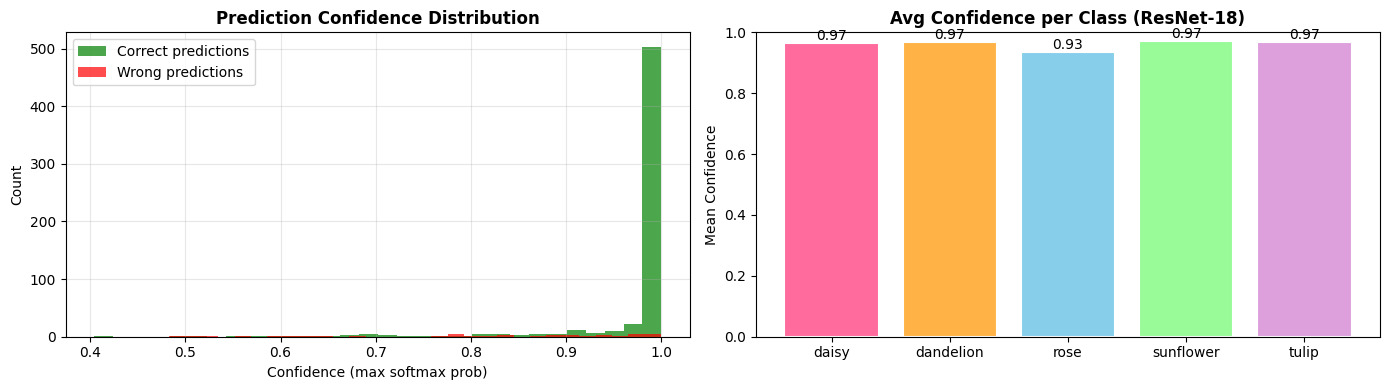

In [20]:
# Confidence = max softmax probability for each prediction
resnet_conf = resnet_probs.max(axis=1)
correct_mask = (resnet_preds == resnet_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram: correct vs wrong confidence
axes[0].hist(resnet_conf[correct_mask],  bins=30, alpha=0.7,
             color="green", label="Correct predictions")
axes[0].hist(resnet_conf[~correct_mask], bins=30, alpha=0.7,
             color="red",   label="Wrong predictions")
axes[0].set_xlabel("Confidence (max softmax prob)")
axes[0].set_ylabel("Count")
axes[0].set_title("Prediction Confidence Distribution", fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Per-class average confidence
per_class_conf = {cls: [] for cls in CLASS_NAMES}
for conf, label in zip(resnet_conf, resnet_labels):
    per_class_conf[CLASS_NAMES[label]].append(conf)

means = [np.mean(v) for v in per_class_conf.values()]
colors = ["#FF6B9D", "#FFB347", "#87CEEB", "#98FB98", "#DDA0DD"]
axes[1].bar(CLASS_NAMES, means, color=colors, edgecolor="white", linewidth=1.5)
axes[1].set_title("Avg Confidence per Class (ResNet-18)", fontweight="bold")
axes[1].set_ylabel("Mean Confidence")
axes[1].set_ylim(0, 1)
for i, m in enumerate(means):
    axes[1].text(i, m + 0.01, f"{m:.2f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## 🖼️ Step 15 — Predict on a New Image

Upload any flower photo and get a prediction with confidence bars!

⬆️  Upload a flower image (jpg/png) ...


Saving yellow-dandelion-flower-sunset-369455505.webp to yellow-dandelion-flower-sunset-369455505.webp


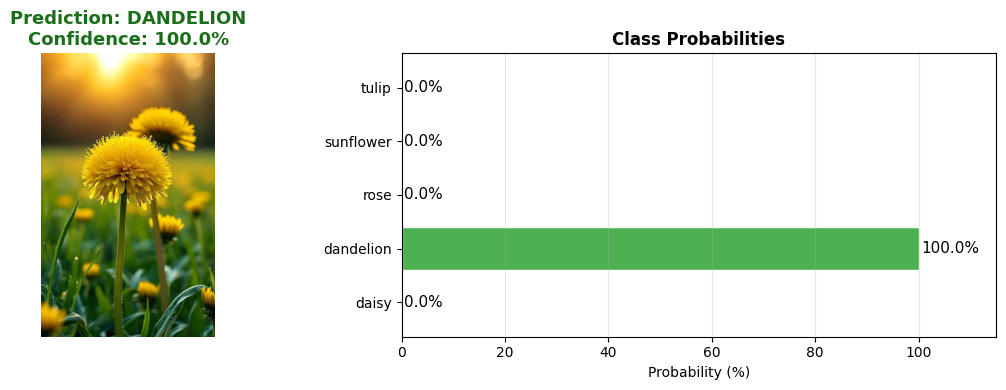


🌸 Predicted class: DANDELION (100.0% confidence)


In [21]:
@torch.no_grad()
def predict_single_image(model, img_path, class_names, transform, device):
    """
    Run the model on one image and display:
    - The image itself
    - Top predicted class with probability bar chart
    """
    model.eval()

    img_pil    = Image.open(img_path).convert("RGB")
    img_tensor = transform(img_pil).unsqueeze(0).to(device)  # (1, 3, 224, 224)

    outputs = model(img_tensor)
    probs   = torch.softmax(outputs, dim=1)[0].cpu().numpy()  # (num_classes,)
    pred_idx = probs.argmax()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: the image
    axes[0].imshow(img_pil)
    axes[0].set_title(
        f"Prediction: {class_names[pred_idx].upper()}\nConfidence: {probs[pred_idx]*100:.1f}%",
        fontsize=13, fontweight="bold",
        color="#1a6e1a" if probs[pred_idx] > 0.7 else "#cc6600"
    )
    axes[0].axis("off")

    # Right: probability bar chart
    bar_colors = ["#4CAF50" if i == pred_idx else "#90CAF9" for i in range(len(class_names))]
    bars = axes[1].barh(class_names, probs * 100, color=bar_colors, edgecolor="white")
    for bar, prob in zip(bars, probs):
        axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f"{prob*100:.1f}%", va="center", fontsize=11)
    axes[1].set_xlim(0, 115)
    axes[1].set_xlabel("Probability (%)")
    axes[1].set_title("Class Probabilities", fontweight="bold")
    axes[1].grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(f"\n🌸 Predicted class: {class_names[pred_idx].upper()} ({probs[pred_idx]*100:.1f}% confidence)")


# ── Upload your own image ─────────────────────────────────────────────────────
print("⬆️  Upload a flower image (jpg/png) ...")
uploaded_img = files.upload()

if uploaded_img:
    img_filename = list(uploaded_img.keys())[0]
    predict_single_image(
        model       = resnet_model,
        img_path    = img_filename,
        class_names = CLASS_NAMES,
        transform   = val_test_transforms,
        device      = DEVICE,
    )

## 💾 Step 16 — Save & Load Models

Save your trained models so you don't lose them when Colab restarts.

In [22]:
# ── Save a complete checkpoint (weights + class mapping) ──────────────────────
checkpoint = {
    "model_state_dict" : resnet_model.state_dict(),
    "class_names"      : CLASS_NAMES,
    "num_classes"      : NUM_CLASSES,
    "architecture"     : "resnet18",
    "val_accuracy"     : max(resnet_history["val_acc"]),
}
torch.save(checkpoint, "flower_resnet18_final.pth")
print("✅ Saved: flower_resnet18_final.pth")

# ── Download to your computer ─────────────────────────────────────────────────
files.download("flower_resnet18_final.pth")

✅ Saved: flower_resnet18_final.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
# ── How to LOAD the checkpoint later ─────────────────────────────────────────
def load_flower_model(checkpoint_path, device):
    """Re-create the model and load saved weights."""
    ckpt = torch.load(checkpoint_path, map_location=device)

    model = build_resnet_model(ckpt["num_classes"], freeze_backbone=False)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device).eval()

    print(f"✅ Model loaded! Classes: {ckpt['class_names']}")
    print(f"   Best val accuracy: {ckpt['val_accuracy']*100:.2f}%")
    return model, ckpt["class_names"]

# Example usage:
# loaded_model, class_names = load_flower_model("flower_resnet18_final.pth", DEVICE)

## 📊 Step 17 — Final Summary & Comparison


           🌸 FINAL RESULTS SUMMARY 🌸
Model                              Params   Test Acc
----------------------------------------------------
Custom CNN                        587,269     70.63%
ResNet-18 (Transfer Learning)   11,309,125     93.20%

🏆 Winner: ResNet-18


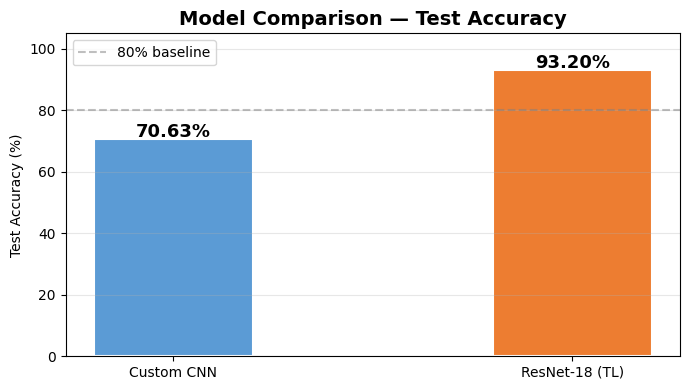

In [24]:
cnn_test_acc    = (cnn_preds    == cnn_labels).mean()    * 100
resnet_test_acc = (resnet_preds == resnet_labels).mean() * 100
cnn_params    = sum(p.numel() for p in cnn_model.parameters())
resnet_params = sum(p.numel() for p in resnet_model.parameters())

print("\n" + "="*60)
print("           🌸 FINAL RESULTS SUMMARY 🌸")
print("="*60)
print(f"{'Model':<28} {'Params':>12} {'Test Acc':>10}")
print("-" * 52)
print(f"{'Custom CNN':<28} {cnn_params:>12,} {cnn_test_acc:>9.2f}%")
print(f"{'ResNet-18 (Transfer Learning)':<28} {resnet_params:>12,} {resnet_test_acc:>9.2f}%")
print("="*60)

winner = "ResNet-18" if resnet_test_acc > cnn_test_acc else "Custom CNN"
print(f"\n🏆 Winner: {winner}")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(7, 4))
models_names = ["Custom CNN", "ResNet-18 (TL)"]
accs = [cnn_test_acc, resnet_test_acc]
bars = ax.bar(models_names, accs, color=["#5B9BD5", "#ED7D31"], width=0.4,
              edgecolor="white", linewidth=1.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{acc:.2f}%", ha="center", fontsize=13, fontweight="bold")
ax.set_ylim(0, 105)
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Model Comparison — Test Accuracy", fontsize=14, fontweight="bold")
ax.axhline(y=80, color="gray", linestyle="--", alpha=0.5, label="80% baseline")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()